In [70]:
import pandas as pd
from matplotlib import pyplot as plt

# Load data into dataframe
df = pd.read_csv("data/master_cleaned.csv", header=0)
#print(df.head(2)) # Test that the dataframe works

## Story 1: Memecoins are more volatile compared to Bitcoin

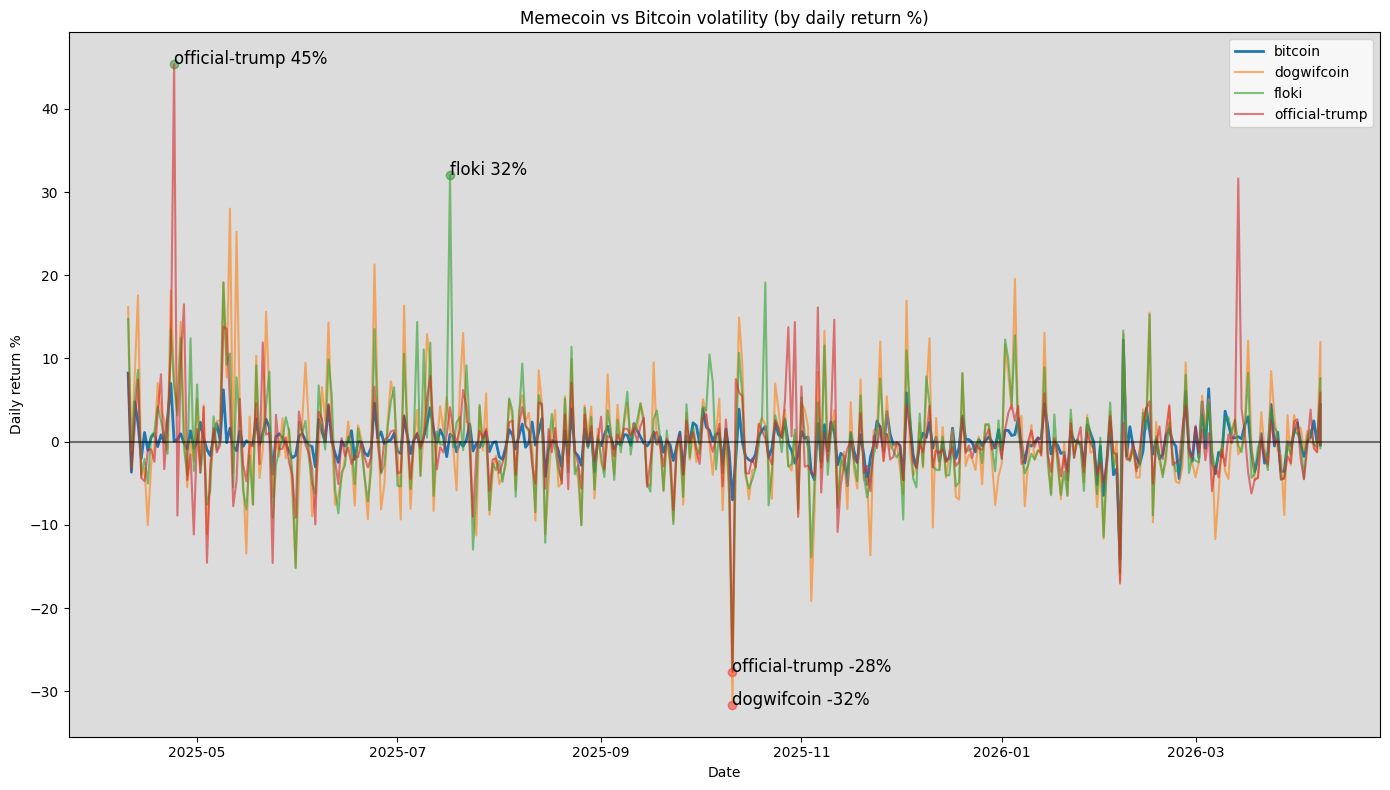

In [ ]:
plt.figure(figsize = (14,8))

df["date"] = pd.to_datetime(df["date"])

# Limit dates to only show a year
cutoff = df["date"].max() - pd.Timedelta(days=365)
df = df[df["date"] >= cutoff].copy()

# Go through each coin and plot them
for coin_id, d in df.groupby("coin_id"):
    d = d.sort_values("date")

    # Highlight bitcoin to make it easy to find
    if coin_id == "bitcoin":
        plt.plot(d["date"], d["daily_return_pct"], label = coin_id, linewidth = 2, alpha = 1)
    else:
        plt.plot(d["date"], d["daily_return_pct"], label = coin_id, alpha = 0.6)

# Find a few extreme values to point out
extremes = pd.concat([
    df.nlargest(2, "daily_return_pct"),
    df.nsmallest(2, "daily_return_pct"),
])
for _, row in extremes.iterrows():
    color = "green" if row["daily_return_pct"] > 0 else "red" # display positive return as green, negative as red
    plt.scatter(row["date"], row["daily_return_pct"], color = color, alpha = 0.4)
    plt.text(row["date"], row["daily_return_pct"],
             f"{row["coin_id"]} {row["daily_return_pct"]:.0f}%",
             fontsize = 12)

ax = plt.gca()
ax.set_facecolor("gainsboro")
plt.axhline(0, color = "black", alpha = 0.5)
plt.title("Memecoin vs Bitcoin volatility (by daily return %)")
plt.xlabel("Date")
plt.ylabel("Daily return %")
plt.legend()
plt.tight_layout()
plt.show()

Two coins have similar negative return on same or around same date. Information about events for that date could then be retrieved and displayed to educate users. Users could also search up the coin and the date of the large "dip".